### Analyse exploratoire des données

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [181]:
building_consumptions = pd.read_csv('2016_Building_Energy_Benchmarking.csv')
building_consumptions.head()


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [182]:
### Nombre de lignes colonnes et de doublons
print('----------------- Analyse Exploiratoire du dataset')
print(f' Le nombre de ligne est {building_consumptions.shape[0]}')
print(f' Le nombre de colonne est {building_consumptions.shape[1]}')
print(f' Le nombre de doublon est {building_consumptions.duplicated().sum()}')

----------------- Analyse Exploiratoire du dataset
 Le nombre de ligne est 3376
 Le nombre de colonne est 46
 Le nombre de doublon est 0


#### Etudions les colonnes en regardant leur structure

In [183]:
# Mehode 1
for col in building_consumptions.columns:
    print(f"Colonne : {col}")
    print(building_consumptions[col].value_counts())
    print("--------------")

Colonne : OSEBuildingID
OSEBuildingID
1        1
25062    1
24943    1
24948    1
24955    1
        ..
20985    1
20986    1
20987    1
20988    1
50226    1
Name: count, Length: 3376, dtype: int64
--------------
Colonne : DataYear
DataYear
2016    3376
Name: count, dtype: int64
--------------
Colonne : BuildingType
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64
--------------
Colonne : PrimaryPropertyType
PrimaryPropertyType
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             133
High-Rise Multifamily          105
Retail Store                  

In [184]:
# Methode 2
for i in building_consumptions.columns:
    print(building_consumptions[i].value_counts())
    print("--------------------------")

OSEBuildingID
1        1
25062    1
24943    1
24948    1
24955    1
        ..
20985    1
20986    1
20987    1
20988    1
50226    1
Name: count, Length: 3376, dtype: int64
--------------------------
DataYear
2016    3376
Name: count, dtype: int64
--------------------------
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64
--------------------------
PrimaryPropertyType
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             133
High-Rise Multifamily          105
Retail Store                    91
Hotel                           77
Worship Facility    

### On va se reisteindre uniquement aux bâtiments Concerné c'est à dire les bâtiments non residentiels

In [185]:
data = building_consumptions.copy()

In [186]:
data.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [187]:
non_residential_types = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA"
]

data = data[data["BuildingType"].isin(non_residential_types)]
data["BuildingType"].value_counts()

BuildingType
NonResidential        1460
Nonresidential COS      85
Nonresidential WA        1
Name: count, dtype: int64

### Idenfication des colonnes pouvant aider à réperer les bâtiments aberrants ou peu pertinents

In [188]:
data.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [189]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1546 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1546 non-null   int64  
 1   DataYear                         1546 non-null   int64  
 2   BuildingType                     1546 non-null   object 
 3   PrimaryPropertyType              1546 non-null   object 
 4   PropertyName                     1546 non-null   object 
 5   Address                          1546 non-null   object 
 6   City                             1546 non-null   object 
 7   State                            1546 non-null   object 
 8   ZipCode                          1530 non-null   float64
 9   TaxParcelIdentificationNumber    1546 non-null   object 
 10  CouncilDistrictCode              1546 non-null   int64  
 11  Neighborhood                     1546 non-null   object 
 12  Latitude                 

<Axes: xlabel='PropertyGFATotal', ylabel='PrimaryPropertyType'>

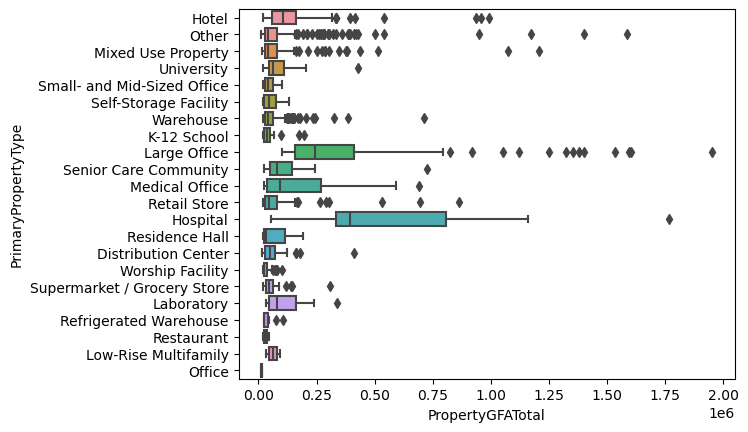

In [190]:
sns.boxplot(data= data , x ='PropertyGFATotal', y ='PrimaryPropertyType')

<Axes: xlabel='BuildingType', ylabel='NumberofFloors'>

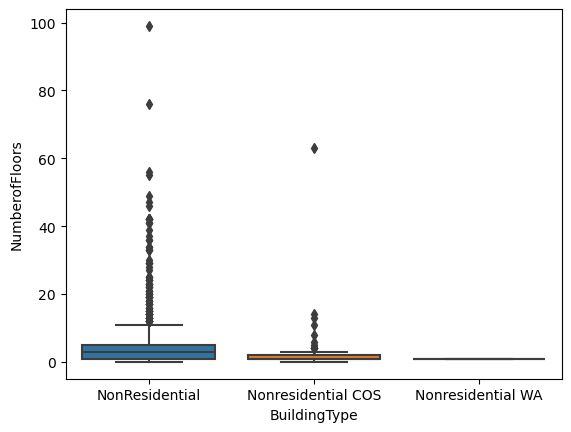

In [191]:
sns.boxplot(data = data , y ='NumberofFloors', x = "BuildingType")

<Axes: xlabel='BuildingType', ylabel='PropertyGFATotal'>

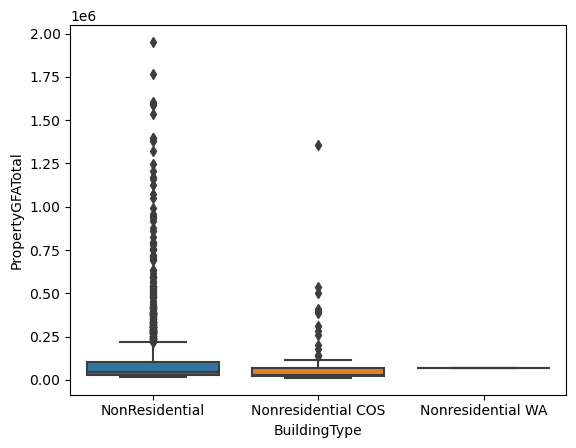

In [192]:
sns.boxplot(data= data , y ='PropertyGFATotal', x ='BuildingType')

### Choix de la colonne candidate

Nous choisissons la colonne SiteEneryUse(kbtu) comme target , car l'objectif principal est de determiner la consommation énergetique des bâtiments non destinés à l'habitation 

In [193]:
data.isna().sum()

OSEBuildingID                         0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
City                                  0
State                                 0
ZipCode                              16
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     2
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             2
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
SecondLargestPropertyUseType        704
SecondLargestPropertyUseTypeGFA     704


In [194]:
data.shape[0]

1546

In [195]:
data['BuildingType']

0           NonResidential
1           NonResidential
2           NonResidential
3           NonResidential
4           NonResidential
               ...        
3371    Nonresidential COS
3372    Nonresidential COS
3373    Nonresidential COS
3374    Nonresidential COS
3375    Nonresidential COS
Name: BuildingType, Length: 1546, dtype: object

<Axes: xlabel='BuildingType', ylabel='PropertyGFATotal'>

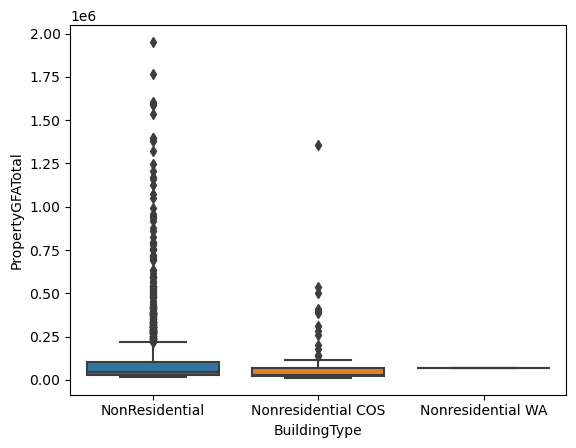

In [196]:
sns.boxplot(data= data , y ='PropertyGFATotal', x ='BuildingType')

#### Features Engineering

### Interressons à l'âge des bâtiments en faisant la soustraction entre l'année de construction et l'année en cours

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


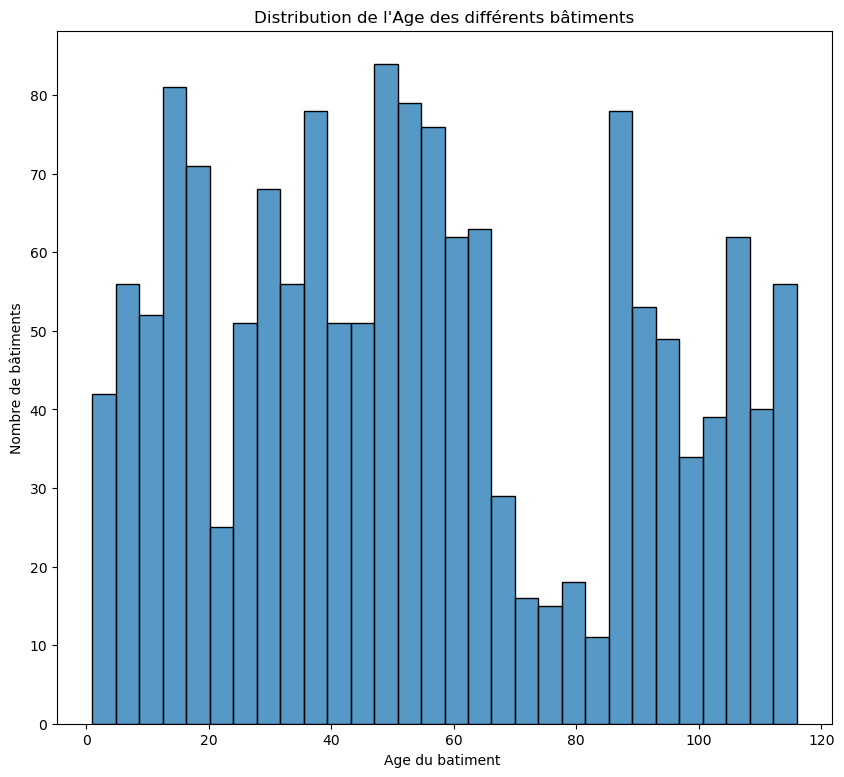

In [197]:
data['age_bat'] = data['DataYear'] - data['YearBuilt']
data['age_bat']
## Traçons la distribution
fig = plt.figure(figsize = (10, 9))
ax = sns.histplot(data = data, x = 'age_bat', bins = 30)
ax.set_xlabel("Age du batiment ")
ax.set_ylabel ("Nombre de bâtiments")
plt.title ("Distribution de l'Age des différents bâtiments")
plt.show()

### En d'autres termes voyons commment l'energie se comporte en fonction de la surface 

In [198]:
dfa = data.copy()

In [199]:
dfa['Energy_per_m2'] = (
   dfa['SiteEnergyUse(kBtu)'] /
    dfa['PropertyGFATotal']
)

In [200]:
dfa['Energy_per_m2']

0        81.714753
1        80.991184
2        75.919114
3       110.805349
4        80.718795
           ...    
3371     69.118732
3372     59.392262
3373    438.238048
3374     51.022707
3375     63.144717
Name: Energy_per_m2, Length: 1546, dtype: float64

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


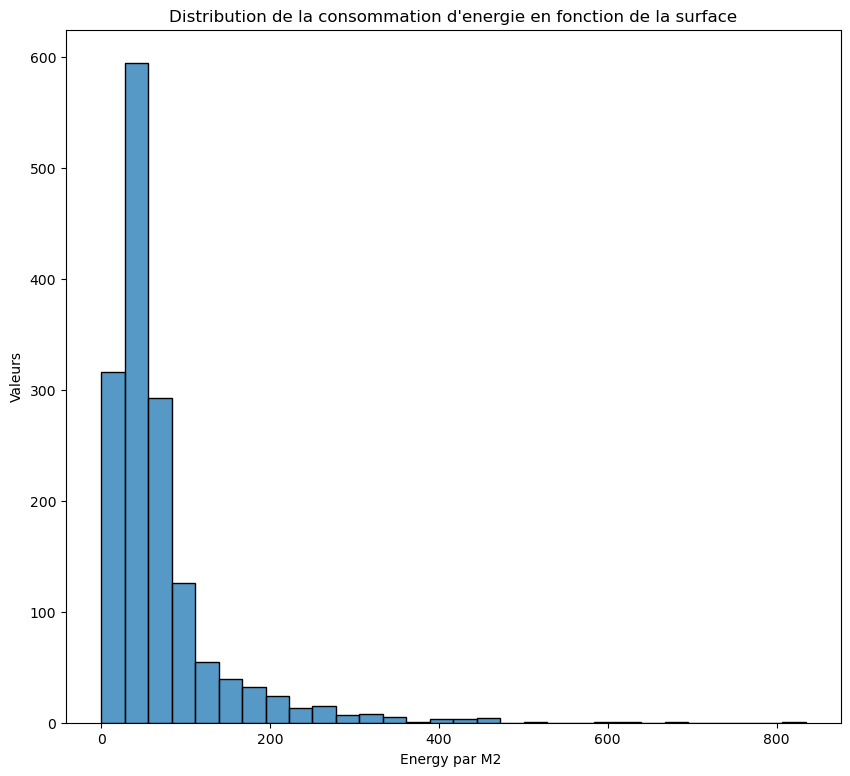

In [201]:
fig = plt.figure(figsize = (10, 9))
ax = sns.histplot(data = dfa, x = 'Energy_per_m2', bins = 30)
ax.set_xlabel("Energy par M2 ")
ax.set_ylabel ("Valeurs")
plt.title ("Distribution de la consommation d'energie en fonction de la surface")
plt.show()

### Suppressions des colonnes

On nous a donnée comme information que Pour se fier à ce qui est dit nous allons maintenant éviter de prendre les colonnes pour les quelles  Les valeurs des sources d'énergies (gaz, électricité) ne peuvent pas être utilisées, car cela créerait du data leakage.

In [202]:
df = dfa.copy()

In [203]:
df.columns.nunique()

48

In [204]:
df = df.drop(['Comments'], axis = 1)

In [205]:
df= df.drop(['DataYear'], axis = 1)
df.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'DefaultData', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions',
       

In [206]:
df = df.drop(['Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber','YearBuilt','PropertyGFAParking','ListOfAllPropertyUseTypes','SecondLargestPropertyUseType','SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified','SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)','SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)','DefaultData', 'ComplianceStatus', 'Outlier','GHGEmissionsIntensity'], axis = 1)

In [207]:
df.columns.nunique()

19

In [208]:
df.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'TotalGHGEmissions', 'age_bat', 'Energy_per_m2'],
      dtype='object')

In [209]:
df = df.drop(['CouncilDistrictCode','Neighborhood','Latitude','Longitude' ], axis = 1 )

In [210]:
df.columns.nunique()

15

In [211]:
df = df.drop(['OSEBuildingID'], axis = 1)

In [212]:
df.columns

Index(['BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'TotalGHGEmissions', 'age_bat', 'Energy_per_m2'],
      dtype='object')

In [213]:
#df = df.drop(['PropertyName'], axis = 1)
df.select_dtypes(include=['object']).nunique()

BuildingType                 3
PrimaryPropertyType         22
PropertyName              1543
LargestPropertyUseType      56
dtype: int64

In [214]:
df.columns.nunique()

14

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='SiteEnergyUse(kBtu)', ylabel='Count'>

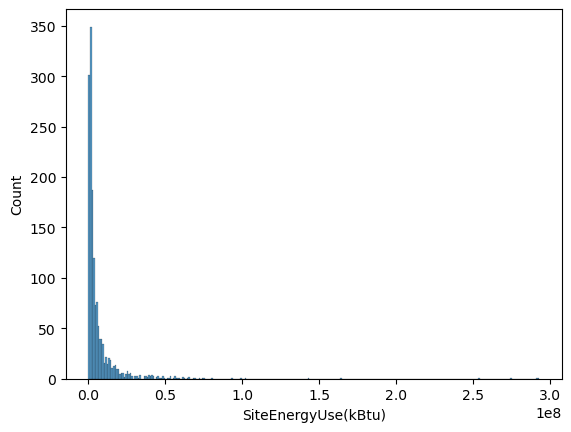

In [215]:
sns.histplot(df['SiteEnergyUse(kBtu)'])

Nous constatons une forte asymetrie à droite et une approximation à O donc nous devons faire le logarithme de siteEneryUse

In [216]:
df['SiteEnergyUse_log'] = np.log1p(
    df['SiteEnergyUse(kBtu)']
)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


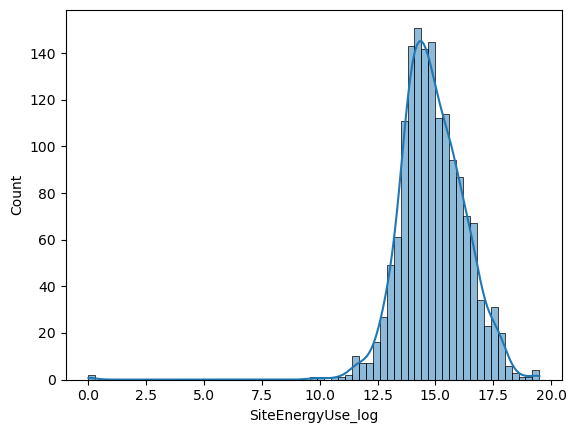

In [217]:
sns.histplot(df['SiteEnergyUse_log'], kde = True)
plt.show()

Nous observons une visualisation plus symetrique

In [218]:
colonnes_quantitative = df.select_dtypes(include=['int64','float64'])

In [219]:
corr = colonnes_quantitative.corr()
corr

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions,age_bat,Energy_per_m2,SiteEnergyUse_log
NumberofBuildings,1.000000,-0.006206,0.169511,0.200249,0.236763,-0.029787,0.407853,0.492796,-0.033717,0.082595,0.133156
NumberofFloors,-0.006206,1.000000,0.677521,0.641002,0.645126,0.147682,0.390685,0.189213,-0.103982,-0.009427,0.399405
PropertyGFATotal,0.169511,0.677521,1.000000,0.978800,0.951053,0.141730,0.638535,0.457778,-0.227724,-0.005607,0.509721
PropertyGFABuilding(s),0.200249,0.641002,0.978800,1.000000,0.948719,0.133009,0.660096,0.497686,-0.182956,0.008382,0.486297
LargestPropertyUseTypeGFA,0.236763,0.645126,0.951053,0.948719,1.000000,0.128766,0.692508,0.557444,-0.195644,0.029048,0.500897
ENERGYSTARScore,-0.029787,0.147682,0.141730,0.133009,0.128766,1.000000,-0.043745,-0.084571,0.048245,-0.334179,-0.154969
SiteEnergyUse(kBtu),0.407853,0.390685,0.638535,0.660096,0.692508,-0.043745,1.000000,0.881052,-0.153426,0.400973,0.570926
TotalGHGEmissions,0.492796,0.189213,0.457778,0.497686,0.557444,-0.084571,0.881052,1.000000,-0.079084,0.328021,0.424560
age_bat,-0.033717,-0.103982,-0.227724,-0.182956,-0.195644,0.048245,-0.153426,-0.079084,1.000000,-0.085363,-0.242794
Energy_per_m2,0.082595,-0.009427,-0.005607,0.008382,0.029048,-0.334179,0.400973,0.328021,-0.085363,1.000000,0.503631


<Axes: >

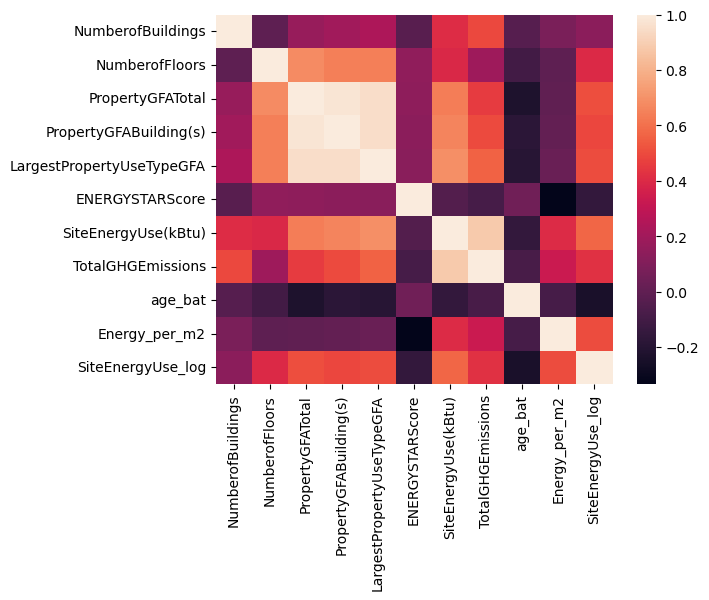

In [220]:
sns.heatmap(corr)

In [221]:
df.columns

Index(['BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'TotalGHGEmissions', 'age_bat', 'Energy_per_m2', 'SiteEnergyUse_log'],
      dtype='object')

In [222]:
df['Energy_per_m2'].isna().sum()

2

In [223]:
df['LargestPropertyUseType'].isna().sum()

6

In [224]:
df['LargestPropertyUseTypeGFA'].isna().sum()

6

In [225]:
df['NumberofBuildings'].isna().sum()

2

In [226]:
df['NumberofFloors'].isna().sum()

0

In [227]:
df['PrimaryPropertyType'].isna().sum()

0

In [228]:
df['PropertyGFABuilding(s)'].isna().sum()

0

In [229]:
df['PropertyGFATotal'].isna().sum()

0

In [230]:
df['SiteEnergyUse(kBtu)'].isna().sum()

2

In [231]:
df['SiteEnergyUse_log'].isna().sum()

2

In [232]:
df['TotalGHGEmissions'].isna().sum()

2

In [233]:
df['age_bat'].isna().sum()

0

In [234]:
df = df.drop(['ENERGYSTARScore'], axis = 1)

In [235]:
df.columns

Index(['BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SiteEnergyUse(kBtu)', 'TotalGHGEmissions',
       'age_bat', 'Energy_per_m2', 'SiteEnergyUse_log'],
      dtype='object')

In [236]:
df = df.dropna()

In [237]:
df['SiteEnergyUse_log'].isna().sum()

0

In [238]:
df.isna().sum()

BuildingType                 0
PrimaryPropertyType          0
PropertyName                 0
NumberofBuildings            0
NumberofFloors               0
PropertyGFATotal             0
PropertyGFABuilding(s)       0
LargestPropertyUseType       0
LargestPropertyUseTypeGFA    0
SiteEnergyUse(kBtu)          0
TotalGHGEmissions            0
age_bat                      0
Energy_per_m2                0
SiteEnergyUse_log            0
dtype: int64

### Modélisation

In [239]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


In [240]:
my_data = df.copy()

In [241]:
qualitative = my_data.select_dtypes(include=["object", "category"]).columns.tolist()

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

ohe.fit(my_data[qualitative])

encoder_transforming = ohe.transform(my_data[qualitative])

df_ohe = pd.DataFrame(
    data=encoder_transforming,
    columns=ohe.get_feature_names_out(qualitative),
    index=my_data.index
)
df_ohe.describe()

,BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,PrimaryPropertyType_Distribution Center,PrimaryPropertyType_Hospital,PrimaryPropertyType_Hotel,PrimaryPropertyType_K-12 School,PrimaryPropertyType_Laboratory,PrimaryPropertyType_Large Office,PrimaryPropertyType_Low-Rise Multifamily,...,LargestPropertyUseType_Restaurant,LargestPropertyUseType_Retail Store,LargestPropertyUseType_Self-Storage Facility,LargestPropertyUseType_Senior Care Community,LargestPropertyUseType_Social/Meeting Hall,LargestPropertyUseType_Strip Mall,LargestPropertyUseType_Supermarket/Grocery Store,LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient,LargestPropertyUseType_Wholesale Club/Supercenter,LargestPropertyUseType_Worship Facility
count,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,...,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000
mean,0.944156,0.055195,0.000649,0.034416,0.006494,0.048701,0.025325,0.006494,0.111688,0.001299,...,0.007143,0.062987,0.017532,0.012987,0.006494,0.003896,0.026623,0.002597,0.000649,0.046104
std,0.229695,0.228434,0.025482,0.182353,0.080346,0.215313,0.157160,0.080346,0.315085,0.036026,...,0.084240,0.243019,0.131287,0.113255,0.080346,0.062317,0.161032,0.050915,0.025482,0.209778
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [242]:
quantitatives = my_data.select_dtypes(include=['int64','float64'])
Final_data =pd.concat([quantitatives, df_ohe], axis=1)


In [243]:
Final_data.columns

Index(['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'age_bat', 'Energy_per_m2',
       'SiteEnergyUse_log',
       ...
       'LargestPropertyUseType_Restaurant',
       'LargestPropertyUseType_Retail Store',
       'LargestPropertyUseType_Self-Storage Facility',
       'LargestPropertyUseType_Senior Care Community',
       'LargestPropertyUseType_Social/Meeting Hall',
       'LargestPropertyUseType_Strip Mall',
       'LargestPropertyUseType_Supermarket/Grocery Store',
       'LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient',
       'LargestPropertyUseType_Wholesale Club/Supercenter',
       'LargestPropertyUseType_Worship Facility'],
      dtype='object', length=1628)

In [244]:
Prediction = Final_data.copy()

### Séparation du jeux de données en X et y

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [245]:
New = Prediction.copy()
New.columns

Index(['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'age_bat', 'Energy_per_m2',
       'SiteEnergyUse_log',
       ...
       'LargestPropertyUseType_Restaurant',
       'LargestPropertyUseType_Retail Store',
       'LargestPropertyUseType_Self-Storage Facility',
       'LargestPropertyUseType_Senior Care Community',
       'LargestPropertyUseType_Social/Meeting Hall',
       'LargestPropertyUseType_Strip Mall',
       'LargestPropertyUseType_Supermarket/Grocery Store',
       'LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient',
       'LargestPropertyUseType_Wholesale Club/Supercenter',
       'LargestPropertyUseType_Worship Facility'],
      dtype='object', length=1628)

In [246]:
Pred = New.copy()
Pred.columns

Index(['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'age_bat', 'Energy_per_m2',
       'SiteEnergyUse_log',
       ...
       'LargestPropertyUseType_Restaurant',
       'LargestPropertyUseType_Retail Store',
       'LargestPropertyUseType_Self-Storage Facility',
       'LargestPropertyUseType_Senior Care Community',
       'LargestPropertyUseType_Social/Meeting Hall',
       'LargestPropertyUseType_Strip Mall',
       'LargestPropertyUseType_Supermarket/Grocery Store',
       'LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient',
       'LargestPropertyUseType_Wholesale Club/Supercenter',
       'LargestPropertyUseType_Worship Facility'],
      dtype='object', length=1628)

In [247]:
X = Pred.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log','TotalGHGEmissions'], axis = 1)

In [248]:
y = Pred['SiteEnergyUse_log']

In [249]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2 , random_state = 42)

In [250]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [251]:
model_svr = SVR()
model_svr.fit(X_train, y_train)

SVR()

In [252]:
y_pred_model_svr = model_svr.predict(X_train)
y_pred_model_svr = model_svr.predict(X_test)

In [253]:
r2_model_svr = r2_score(y_test, y_pred_model_svr)
MAE_model_svr = mean_absolute_error(y_test, y_pred_model_svr)
RMSE_model_svr = np.sqrt(mean_squared_error(y_test, y_pred_model_svr))

In [254]:
r2_model_svr

0.27439638494621

In [255]:
MAE_model_svr

0.6784690909068805

In [256]:
RMSE_model_svr

1.314189119448353

In [257]:
cv_results = cross_validate(
        model_svr,
        X,
        y,
        cv=5,
        scoring=('r2',
                 'neg_mean_absolute_error',
                 'neg_root_mean_squared_error'),
        return_train_score=True)

In [258]:
cv_results

{'fit_time': array([3.32719374, 2.54108047, 2.85770702, 2.48897672, 3.93262362]),
 'score_time': array([1.19704795, 0.98171711, 1.17181849, 1.07636762, 1.08520007]),
 'test_r2': array([0.20222738, 0.35217808, 0.20044895, 0.20089593, 0.46909802]),
 'train_r2': array([0.42397353, 0.48804008, 0.47359617, 0.45855924, 0.46061513]),
 'test_neg_mean_absolute_error': array([-0.63752954, -0.68824695, -0.64344988, -0.69907994, -0.68898159]),
 'train_neg_mean_absolute_error': array([-0.66153403, -0.64679305, -0.65725841, -0.64398733, -0.64594394]),
 'test_neg_root_mean_squared_error': array([-1.28563767, -1.19729666, -0.89789827, -0.95537756, -0.90802171]),
 'train_neg_root_mean_squared_error': array([-0.98021841, -0.99835351, -1.07735382, -1.06763567, -1.07690135])}

Regression Linéaire

In [259]:
X = Pred.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log','TotalGHGEmissions'], axis = 1)

In [260]:
y = Pred['SiteEnergyUse_log']

In [261]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2 , random_state = 42)

In [262]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [263]:
linear_regre = LinearRegression()
linear_regre.fit(X_train,y_train)

LinearRegression()

In [264]:
y_pred_linear_regre_train = linear_regre.predict(X_train)
y_pred_linear_regre_test = linear_regre.predict(X_test)

In [265]:
r2_linear_regre = r2_score(y_test, y_pred_linear_regre_test)
MAE_linear_regre = mean_absolute_error(y_test, y_pred_linear_regre_test)
RMSE_linear_regre = np.sqrt(mean_squared_error(y_test, y_pred_linear_regre_test))

In [266]:
r2_linear_regre

-0.03596975773785793

In [267]:
MAE_linear_regre

0.9655001679234946

In [268]:
RMSE_linear_regre

1.570296588299467

Dummy Regressor

In [269]:
X = Pred.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log','TotalGHGEmissions'], axis = 1)

In [270]:
y = Pred['SiteEnergyUse_log']

In [271]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2 , random_state = 42)

In [272]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [273]:
dumy_median = DummyRegressor(strategy = 'median')
dumy_median.fit(X_train, y_train)

DummyRegressor(strategy='median')

In [274]:
dumy_mean = DummyRegressor(strategy = 'mean')
dumy_mean.fit(X_train, y_train)

DummyRegressor()

In [275]:
y_pred_dumy_mean_train = dumy_mean.predict(X_train)
y_pred_dumy_mean_test = dumy_mean.predict(X_test)

In [276]:
r2_dumy_mean = r2_score(y_test, y_pred_dumy_mean_test)
MAE_dumy_mean = mean_absolute_error(y_test, y_pred_dumy_mean_test)
RMSE_dumy_mean = np.sqrt(mean_squared_error(y_test, y_pred_dumy_mean_test))

In [277]:
r2_dumy_mean

-0.001888413509627096

In [278]:
y_pred_dumy_median_train = dumy_median.predict(X_train)
y_pred_dumy_median_test = dumy_median.predict(X_test)

In [279]:
r2_dumy_median = r2_score(y_test, y_pred_dumy_median_test)
MAE_dumy_median = mean_absolute_error(y_test, y_pred_dumy_median_test)
RMSE_dumy_median = np.sqrt(mean_squared_error(y_test, y_pred_dumy_median_test))

In [280]:
r2_dumy_median

-0.0011755395518693312

Random Forest Regressor

In [281]:
X = Pred.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log','TotalGHGEmissions'], axis = 1)

In [282]:
y = Pred['SiteEnergyUse_log']

In [283]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2 , random_state = 42)

In [284]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [285]:
regressor_random = RandomForestRegressor(n_estimators = 200, random_state=42)
regressor_random.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [286]:
y_pred_random_train = regressor_random.predict(X_train)
y_pred_random_test = regressor_random.predict(X_test)

In [287]:
r2_random = r2_score(y_test, y_pred_random_test)
MAE = mean_absolute_error(y_test,y_pred_random_test)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred_random_test))

In [288]:
r2_random

0.6088705973878226

In [289]:
results = {
    "LinearRegression": {
        "R2":  r2_score(y_test, y_pred_linear_regre_test),
        "MAE": mean_absolute_error(y_test, y_pred_linear_regre_test),
        "RMSE":np.sqrt(mean_squared_error(y_test, y_pred_linear_regre_test))
    },
    
    "RandomForest": {
        "R2":  r2_score(y_test, y_pred_random_test),
        "MAE":mean_absolute_error(y_test,y_pred_random_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_random_test))
    },
    
    "SVR": {
        "R2": r2_score(y_test, y_pred_model_svr),
        "MAE": mean_absolute_error(y_test, y_pred_model_svr),
        "RMSE":np.sqrt(mean_squared_error(y_test, y_pred_model_svr))
    },
    
    "Dummy_mean": {
        "R2": r2_score(y_test, y_pred_dumy_mean_test),
        "MAE": mean_absolute_error(y_test, y_pred_dumy_mean_test),
        "RMSE":np.sqrt(mean_squared_error(y_test, y_pred_dumy_mean_test)) 
    },
    
    "Dummy_median": {
        "R2": r2_score(y_test, y_pred_dumy_median_test),
        "MAE": mean_absolute_error(y_test, y_pred_dumy_median_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_dumy_median_test))
    }
}

results_df = pd.DataFrame(results).T
results_df

,R2,MAE,RMSE
LinearRegression,-0.035970,0.965500,1.570297
RandomForest,0.608871,0.110683,0.964869
SVR,0.274396,0.678469,1.314189
Dummy_mean,-0.001888,1.066582,1.544251
Dummy_median,-0.001176,1.061994,1.543701


In [290]:
results_df_sorted = results_df.sort_values(by="R2", ascending=False)
results_df_sorted

,R2,MAE,RMSE
RandomForest,0.608871,0.110683,0.964869
SVR,0.274396,0.678469,1.314189
Dummy_median,-0.001176,1.061994,1.543701
Dummy_mean,-0.001888,1.066582,1.544251
LinearRegression,-0.035970,0.965500,1.570297


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='TotalGHGEmissions', ylabel='Count'>

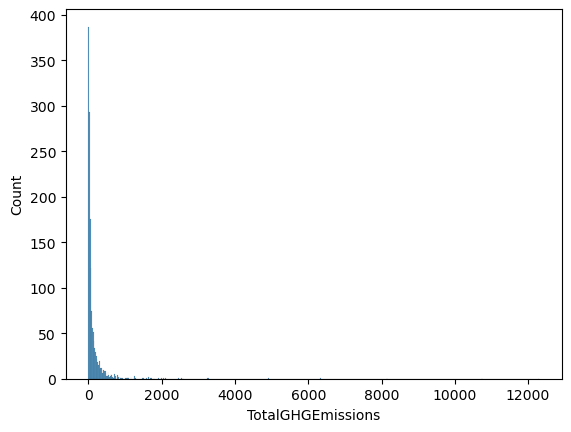

In [291]:
sns.histplot(df['TotalGHGEmissions'])

In [292]:
### Transformons TotalGhEmissions pour qu'il ait une distribution symétrique

In [293]:
Pred['TotalGHEmissions_log'] = np.log1p(
    Pred['TotalGHGEmissions']
)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


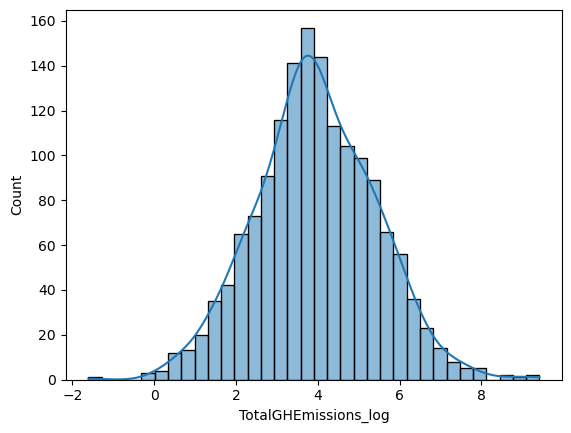

In [294]:
sns.histplot(Pred['TotalGHEmissions_log'], kde = True)
plt.show()

### Predisons pour emissions gaz avec les mêmes modèles!

In [295]:
Pred.columns

Index(['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'age_bat', 'Energy_per_m2',
       'SiteEnergyUse_log',
       ...
       'LargestPropertyUseType_Retail Store',
       'LargestPropertyUseType_Self-Storage Facility',
       'LargestPropertyUseType_Senior Care Community',
       'LargestPropertyUseType_Social/Meeting Hall',
       'LargestPropertyUseType_Strip Mall',
       'LargestPropertyUseType_Supermarket/Grocery Store',
       'LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient',
       'LargestPropertyUseType_Wholesale Club/Supercenter',
       'LargestPropertyUseType_Worship Facility', 'TotalGHEmissions_log'],
      dtype='object', length=1629)

In [296]:
df_GHGE = Pred.copy()
df_GHGE.columns

Index(['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'age_bat', 'Energy_per_m2',
       'SiteEnergyUse_log',
       ...
       'LargestPropertyUseType_Retail Store',
       'LargestPropertyUseType_Self-Storage Facility',
       'LargestPropertyUseType_Senior Care Community',
       'LargestPropertyUseType_Social/Meeting Hall',
       'LargestPropertyUseType_Strip Mall',
       'LargestPropertyUseType_Supermarket/Grocery Store',
       'LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient',
       'LargestPropertyUseType_Wholesale Club/Supercenter',
       'LargestPropertyUseType_Worship Facility', 'TotalGHEmissions_log'],
      dtype='object', length=1629)

### Separation du jeux de données en X et y 

In [297]:
X = df_GHGE.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log', 'TotalGHGEmissions','TotalGHEmissions_log'], axis =1)

In [298]:
y = df_GHGE['TotalGHEmissions_log']

In [299]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [300]:
scaled = StandardScaler()
scaled_X_train = scaled.fit_transform(X_train)
scaled_X_test = scaled.fit_transform(X_test)

In [301]:
### Definissons le modèle

In [302]:
LR = LinearRegression()
LR.fit(X_train, y_train)

LinearRegression()

In [303]:
### Prédictions

In [304]:
y_pred_LR_train = LR.predict(X_train)
y_pred_LR_test = LR.predict(X_test)

In [305]:
### Choix des métriques

In [306]:
r2_LR = r2_score(y_test,y_pred_LR_test )
MAE_LR = mean_absolute_error(y_test, y_pred_LR_test)
RMSE_LR = np.sqrt(mean_squared_error(y_test, y_pred_LR_test))

In [307]:
r2_LR

-1.001346915516811

In [308]:
MAE_LR

1.5581589605905677

In [309]:
RMSE_LR

1.9818023498948547

In [310]:
#### Pour SVR

In [311]:
X = df_GHGE.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log', 'TotalGHGEmissions','TotalGHEmissions_log'], axis =1)

In [312]:
y = df_GHGE['TotalGHEmissions_log']

In [313]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [314]:
scaled = StandardScaler()
scaled_X_train = scaled.fit_transform(X_train)
scaled_X_test = scaled.fit_transform(X_test)

In [315]:
Svr_model = SVR()
Svr_model.fit(X_train,y_train)

SVR()

In [316]:
### Prédictions

In [317]:
y_pred_model = Svr_model.predict(X_train)
y_pred_model_test = Svr_model.predict(X_test)

In [318]:
r2_model = r2_score(y_test,y_pred_model_test)
MAE_model = mean_absolute_error(y_test,y_pred_model_test)
RMSE_model = np.sqrt(mean_squared_error(y_test, y_pred_model_test))

In [319]:
r2_model

0.28238069800898935

In [320]:
MAE_model

0.927371152219815

In [321]:
RMSE_model

1.1867143847396675

In [322]:
### Pour Dummy avec ces deux strategies 


In [323]:
X = df_GHGE.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log', 'TotalGHGEmissions','TotalGHEmissions_log'], axis =1)

In [324]:
y = df_GHGE['TotalGHEmissions_log']

In [325]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [326]:
scaled = StandardScaler()
scaled_X_train = scaled.fit_transform(X_train)
scaled_X_test = scaled.fit_transform(X_test)

In [327]:
model_dum_median = DummyRegressor(strategy='median')
model_dum_median.fit(X_train, y_train)

DummyRegressor(strategy='median')

In [328]:
model_dum_mean = DummyRegressor(strategy='mean')
model_dum_mean.fit(X_train, y_train)

DummyRegressor()

In [329]:
y_pre_dum_mean_train = model_dum_mean.predict(X_train)
y_pre_dum_mean_test = model_dum_mean.predict(X_test)

In [330]:
y_pre_dum_median_train = model_dum_median.predict(X_train)
y_pre_dum_median_test = model_dum_median.predict(X_test)

In [331]:
##Pour Dummy avec stratégie median
r2_dum_med = r2_score(y_test,y_pre_dum_median_test)
MAE_dum_med = mean_absolute_error(y_test,y_pre_dum_median_test)
RMSE_dum_med = np.sqrt(mean_squared_error(y_test, y_pre_dum_median_test))

In [332]:
r2_dum_med

-3.8104692850815525e-05

In [333]:
MAE_dum_med

1.0925624143310526

In [334]:
RMSE_dum_med

1.4009009348480475

In [335]:
##Pour Dummy avec stratégie mean
r2_dum_mean = r2_score(y_test,y_pre_dum_mean_test)
MAE_mean = mean_absolute_error(y_test,y_pre_dum_mean_test)
RMSE_mean = np.sqrt(mean_squared_error(y_test, y_pre_dum_mean_test))

In [336]:
r2_dum_mean

-0.0022789539263687875

In [337]:
MAE_mean

1.0954979614025042

In [338]:
RMSE_mean

1.4024696006733965

In [339]:
### Pour randomForestRegressor

In [340]:
X = df_GHGE.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log', 'TotalGHGEmissions','TotalGHEmissions_log'], axis =1)

In [341]:
y = df_GHGE['TotalGHEmissions_log']

In [342]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [343]:
scaled = StandardScaler()
scaled_X_train = scaled.fit_transform(X_train)
scaled_X_test = scaled.fit_transform(X_test)

In [344]:
model_regressor = RandomForestRegressor(n_estimators=200, random_state=42)
model_regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [345]:
### Prédictions

In [346]:
y_pred_RFR_train = model_regressor.predict(X_train)
y_pred_RFR_test = model_regressor.predict(X_test)

In [347]:
r2_RFR = r2_score(y_test,y_pred_RFR_test)
MAE_RFR = mean_absolute_error(y_test,y_pred_RFR_test)
RMSE_RFR = np.sqrt(mean_squared_error(y_test, y_pred_RFR_test))

In [348]:
r2_RFR

0.771318166987251

In [349]:
MAE_RFR

0.5155191402193875

In [350]:
RMSE_RFR

0.6699077209945139

In [351]:
results_GHGE = {
    "LinearRegression": {
        "R2": r2_score(y_test,y_pred_LR_test ),
        "MAE":  mean_absolute_error(y_test, y_pred_LR_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_LR_test))
    },
    
    "RandomForest": {
        "R2": r2_score(y_test,y_pred_RFR_test), 
        "MAE":  mean_absolute_error(y_test,y_pred_RFR_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_RFR_test))
    },
    
    "SVR": {
        "R2": r2_score(y_test,y_pred_model_test),
        "MAE": mean_absolute_error(y_test,y_pred_model_test),
        "RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_model_test))
    },
    
    "Dummy_mean": {
        "R2":  r2_score(y_test,y_pre_dum_mean_test),
        "MAE":  mean_absolute_error(y_test,y_pre_dum_mean_test),
        "RMSE":  np.sqrt(mean_squared_error(y_test, y_pre_dum_mean_test))
    },
    
    "Dummy_median": {
        "R2": r2_score(y_test,y_pre_dum_median_test),
        "MAE":  mean_absolute_error(y_test,y_pre_dum_median_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pre_dum_median_test))
    }
}

results_df_GHGE = pd.DataFrame(results_GHGE).T
results_df_GHGE

,R2,MAE,RMSE
LinearRegression,-1.001347,1.558159,1.981802
RandomForest,0.771318,0.515519,0.669908
SVR,0.282381,0.927371,1.186714
Dummy_mean,-0.002279,1.095498,1.402470
Dummy_median,-0.000038,1.092562,1.400901


In [352]:
results_df_sorteds = results_df_GHGE.sort_values(by="R2", ascending=False)
results_df_sorteds

,R2,MAE,RMSE
RandomForest,0.771318,0.515519,0.669908
SVR,0.282381,0.927371,1.186714
Dummy_median,-0.000038,1.092562,1.400901
Dummy_mean,-0.002279,1.095498,1.402470
LinearRegression,-1.001347,1.558159,1.981802


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

### Le modèle plus performant que nous avons utiliser dans les deux analyses est RandomForestRegressor 

Effectuons une GridSearchCv sur 3 hyperparamètres

https://github.com/scikit-learn/scikit-learn/blob/d3898d9d5/sklearn/model_selection/_search.py#L1246 Source pour GridSearchCV

Pour SiteEneryUse(kBtu)

In [353]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

regressor_random = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=regressor_random,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1   # utilise tous les coeurs
)

grid_search.fit(X_train, y_train)

#print("Best params:", grid.best_params_)
#print("Best R2:", grid.best_score_)

print(f"Best score: {grid_search.best_score_:.3f}")
print(f"Best parameters: {grid_search.best_params_}")

# Evaluate on test set
best_model = grid_search.best_estimator_
#test_score = best_model.score(X_test, y_test)
#print(f"Test set R^2 score: {test_score:.3f}")


Best score: 0.813
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [354]:
param_grids = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

regressor_random = RandomForestRegressor(random_state=40)

grid_search = GridSearchCV(
    estimator=regressor_random,
    param_grid=param_grids,
    cv=5,
    scoring='r2',
    n_jobs=-1   # utilise tous les coeurs
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best R2:", grid_search.best_score_)

#print(f"Best score: {grid_search.best_score_:.3f}")
#print(f"Best parameters: {grid_search.best_params_}")

# Evaluate on test set
#best_model = grid_search.best_estimator_
#test_score = best_model.score(X_test, y_test)
#print(f"Test set R^2 score: {test_score:.3f}")

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best R2: 0.8135657056737147


Pour TotalGHGEmmissions

In [355]:
X = df_GHGE.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log', 'TotalGHGEmissions','TotalGHEmissions_log'], axis =1)
y = df_GHGE['TotalGHEmissions_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

param_grids = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

model_regressor = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=model_regressor,
    param_grid=param_grids,
    cv=5,
    scoring='r2',
    n_jobs=-1   # utilise tous les coeurs
)

grid_search.fit(X_train, y_train)

### Ajout de la permutation importance

print(f"Best score: {grid_search.best_score_:.3f}")
print(f"Best parameters: {grid_search.best_params_}")

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print(f"Test set R^2 score: {test_score:.3f}")

Best score: 0.813
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Test set R^2 score: 0.770


### Soit à determiner les features qui impactent le modèle pour les 2 cibles SiteEnergyUse(kBtu) et TotalGHGemissions

Utilisons feature importance en 1er 

In [358]:
X = df_GHGE.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log', 'TotalGHGEmissions','TotalGHEmissions_log'], axis =1)

In [359]:
y = df_GHGE['TotalGHEmissions_log']

In [360]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [361]:
rf_regressor = RandomForestRegressor(random_state=42)

In [365]:
features_names = X.columns
rf_regressor.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [366]:
features_names = list(X.columns)

In [363]:
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)
std = np.std([tree.feature_importances_ for tree in rf_regressor.estimators_], axis=0)

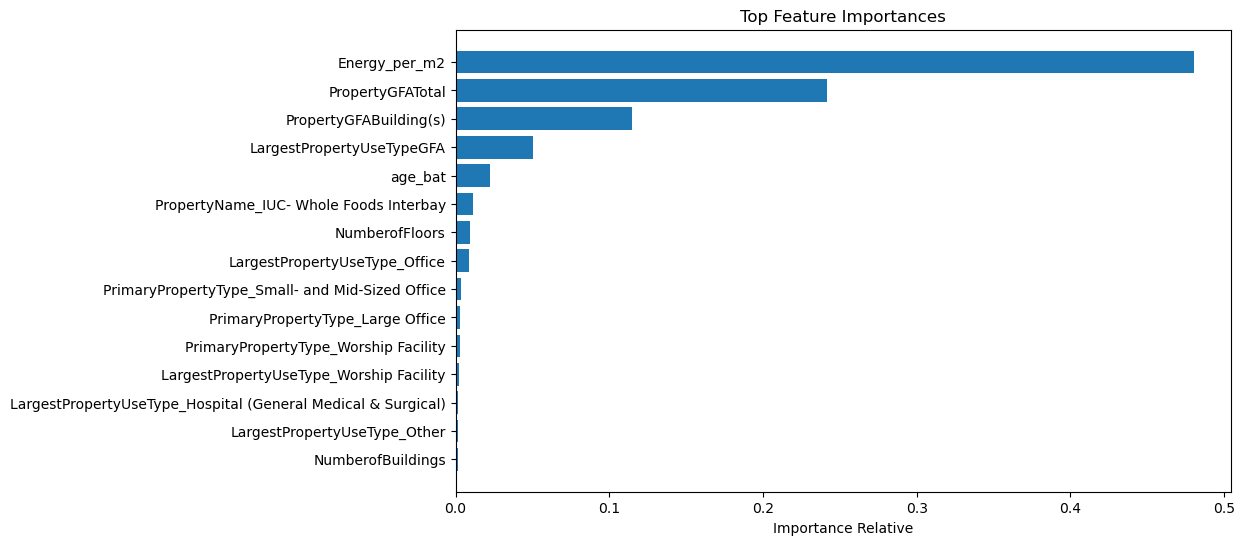

In [369]:
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 15

plt.figure(figsize=(10,6))
plt.title("Top Feature Importances")

plt.barh(range(top_n), importances[indices[:top_n]][::-1])
plt.yticks(range(top_n), [features_names[i] for i in indices[:top_n]][::-1])

plt.xlabel("Importance Relative")
plt.show()

* Permutation importance

In [372]:
resultat = permutation_importance(
    rf_regressor,
    X_train,
    y_train,
    scoring="r2",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

In [375]:
permutation_importances = resultat.importances_mean
permutations_indices = np.argsort(importances)[::-1]

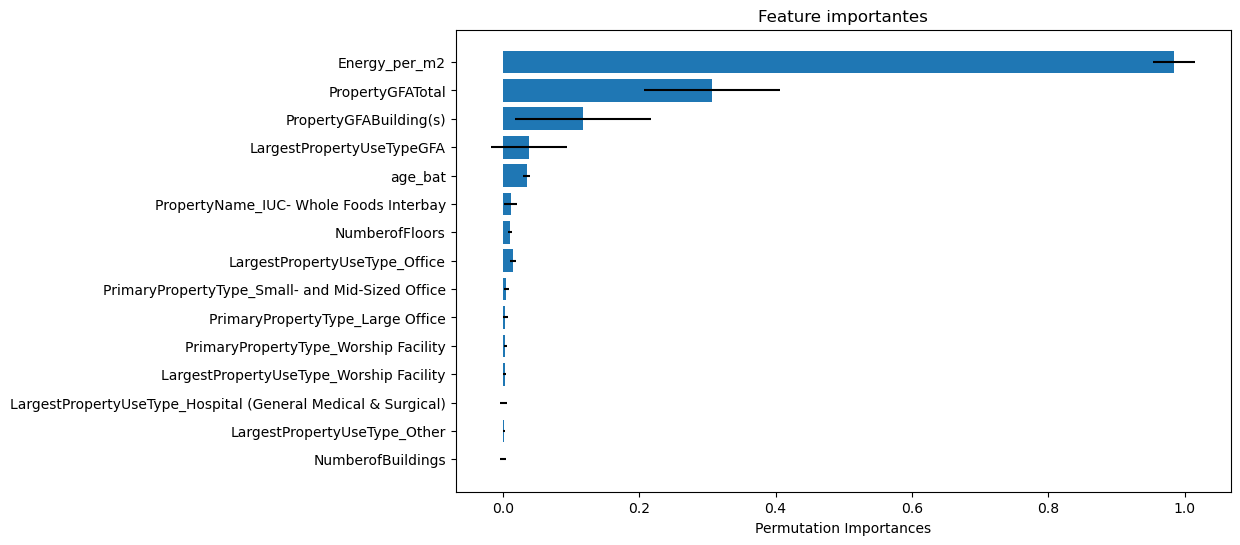

In [376]:
top_values = 15

plt.figure(figsize=(10,6))
plt.title("Feature importantes")

plt.barh(
    range(top_values),
    permutation_importances[permutations_indices[:top_values]][::-1],
    align="center",
    xerr=std[permutations_indices[:top_values]][::-1]
)

plt.yticks(
    range(top_values),
    [features_names[i] for i in permutations_indices[:top_values]][::-1]
)

plt.xlabel("Permutation Importances")
plt.show()

### Pour SiteEnerguUse 

In [392]:
X = Pred.drop(['SiteEnergyUse(kBtu)','SiteEnergyUse_log','TotalGHGEmissions','TotalGHEmissions_log'], axis = 1)

In [393]:
y = Pred['SiteEnergyUse_log']

* Feature importance

In [394]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=41)

In [395]:
rdf = RandomForestRegressor(random_state = 41)

In [396]:
colonnes_features = X.columns
rdf.fit(X_train,y_train)

RandomForestRegressor(random_state=41)

In [397]:
colonnes_features = list(X.columns)

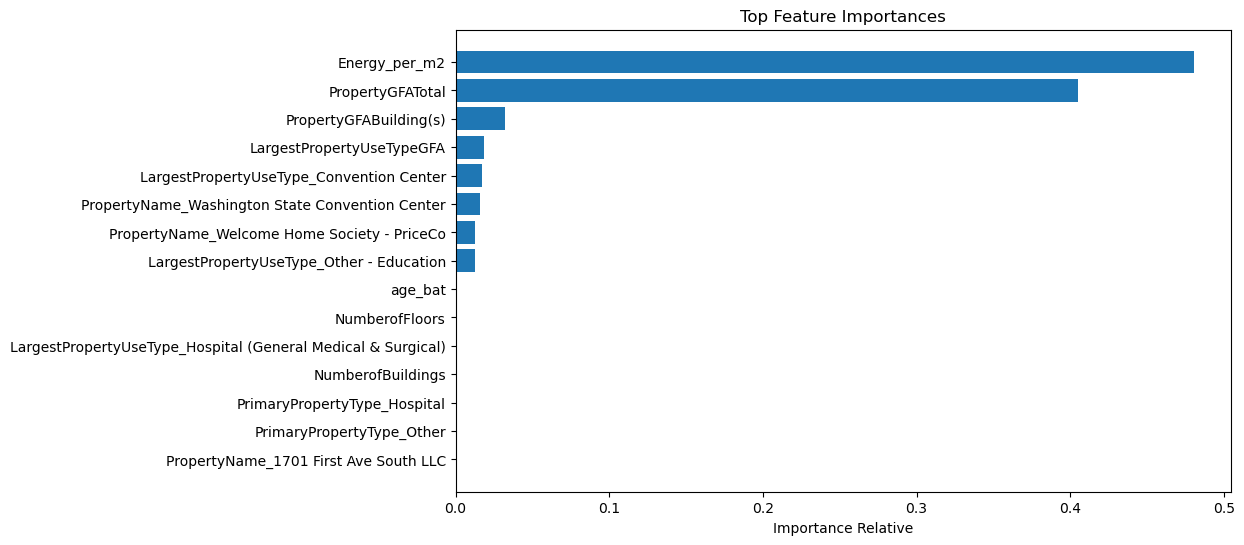

In [398]:
importances_rdf =rdf.feature_importances_
indices_rdf = np.argsort(importances_rdf)[::-1]

n = 15

plt.figure(figsize=(10,6))
plt.title("Top Feature Importances")

plt.barh(range(n), importances_rdf[indices_rdf[:n]][::-1])
plt.yticks(range(n), [colonnes_features[i] for i in indices_rdf[:n]][::-1])

plt.xlabel("Importance Relative")
plt.show()

* Permutation importances

In [402]:
rendu = permutation_importance(
    rdf,
    X_train,
    y_train,
    scoring="r2",
    n_repeats=3,
    random_state=41,
    n_jobs=-1
)

In [406]:
permutation_importances_rdf = rendu.importances_mean
permutations_indices_rdf = np.argsort(importances_rdf)[::-1]

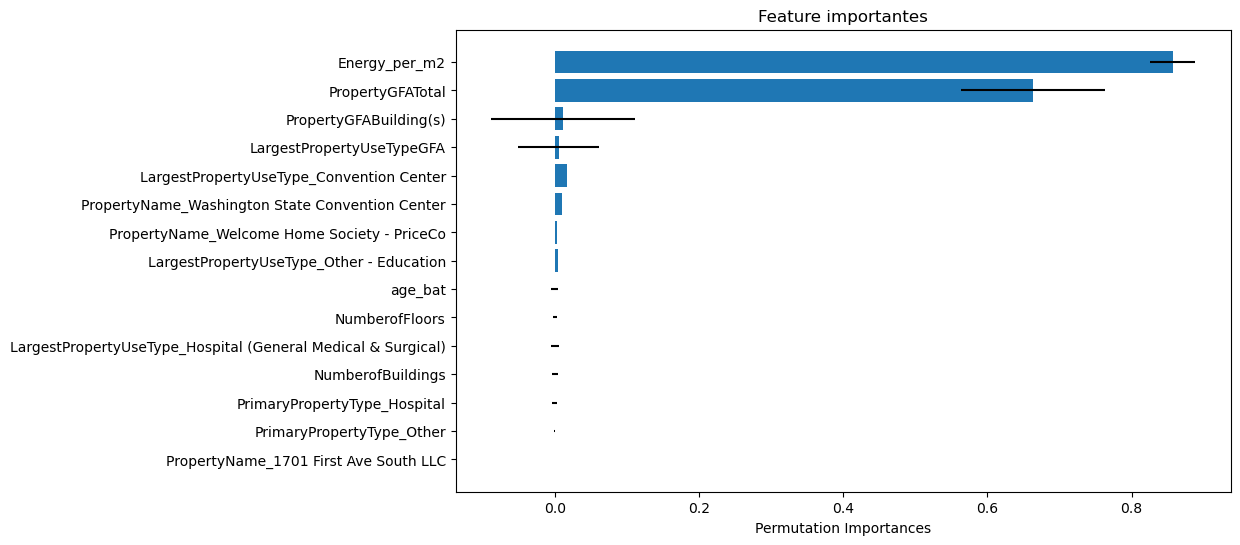

In [409]:
values = 15

plt.figure(figsize=(10,6))
plt.title("Feature importantes")

plt.barh(
    range(values),
    permutation_importances_rdf[permutations_indices_rdf[:values]][::-1],
    align="center",
    xerr=std[permutations_indices_rdf[:values]][::-1]
)

plt.yticks(
    range(values),
    [colonnes_features[i] for i in permutations_indices_rdf[:values]][::-1]
)

plt.xlabel("Permutation Importances")
plt.show()